In [1]:
import ee
from google.colab import auth

auth.authenticate_user()
ee.Initialize(project='forest-carbon-stock-estimation')

print("Earth Engine connected ✅")

Earth Engine connected ✅


In [ ]:
import folium

# Define our study area - Western Ghats, Tamil Nadu (your region!)
study_area = ee.Geometry.Rectangle([77.0, 10.0, 78.5, 11.5])

# Load Sentinel-2 satellite image
sentinel2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(study_area) \
    .filterDate('2023-01-01', '2023-12-31') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)) \
    .median()

# Visualization parameters - True color (what human eyes see)
vis_params = {
    'min': 0,
    'max': 3000,
    'bands': ['B4', 'B3', 'B2']  # Red, Green, Blue
}

# Get map URL
map_id = sentinel2.getMapId(vis_params)

# Create interactive map
m = folium.Map(location=[10.75, 77.75], zoom_start=8)
folium.TileLayer(
    tiles=map_id['tile_fetcher'].url_format,
    attr='Google Earth Engine',
    name='Sentinel-2 True Color',
    overlay=True,
    control=True
).add_to(m)

folium.LayerControl().add_to(m)

# Display map
m

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Define our study area - Western Ghats, Tamil Nadu
study_area = ee.Geometry.Rectangle([77.0, 10.0, 78.5, 11.5])

# Load Sentinel-2 image
sentinel2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(study_area) \
    .filterDate('2023-01-01', '2023-12-31') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)) \
    .median()

# Calculate NDVI
ndvi = sentinel2.normalizedDifference(['B8', 'B4']).rename('NDVI')

# Extract NDVI statistics for our study area
ndvi_stats = ndvi.reduceRegion(
    reducer=ee.Reducer.mean()
        .combine(ee.Reducer.min(), sharedInputs=True)
        .combine(ee.Reducer.max(), sharedInputs=True)
        .combine(ee.Reducer.stdDev(), sharedInputs=True),
    geometry=study_area,
    scale=1000,
    maxPixels=1e9
)

stats = ndvi_stats.getInfo()
print("📊 NDVI Statistics for Western Ghats, Tamil Nadu:")
print(f"Mean NDVI:  {stats['NDVI_mean']:.4f}")
print(f"Min NDVI:   {stats['NDVI_min']:.4f}")
print(f"Max NDVI:   {stats['NDVI_max']:.4f}")
print(f"Std Dev:    {stats['NDVI_stdDev']:.4f}")

📊 NDVI Statistics for Western Ghats, Tamil Nadu:
Mean NDVI:  0.4460
Min NDVI:   -0.3475
Max NDVI:   0.8870
Std Dev:    0.1535


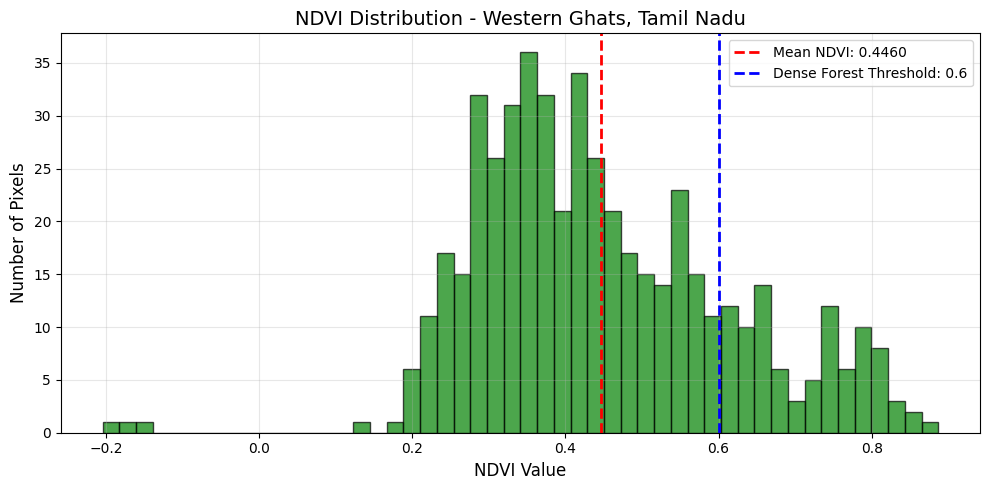

Chart saved! ✅


In [4]:
# Sample NDVI values from the region
ndvi_sample = ndvi.sample(
    region=study_area,
    scale=1000,
    numPixels=500,
    seed=42
)

# Convert to list
ndvi_values = ndvi_sample.aggregate_array('NDVI').getInfo()

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(ndvi_values, bins=50, color='green', edgecolor='black', alpha=0.7)
plt.axvline(x=0.4460, color='red', linestyle='--', linewidth=2, label=f'Mean NDVI: 0.4460')
plt.axvline(x=0.6, color='blue', linestyle='--', linewidth=2, label='Dense Forest Threshold: 0.6')
plt.xlabel('NDVI Value', fontsize=12)
plt.ylabel('Number of Pixels', fontsize=12)
plt.title('NDVI Distribution - Western Ghats, Tamil Nadu', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ndvi_distribution.png', dpi=150)
plt.show()
print("Chart saved! ✅")

In [5]:
# Load NASA GEDI Level 4A Biomass Data
gedi = ee.ImageCollection('LARSE/GEDI/GEDI04_A_002_MONTHLY') \
    .filterBounds(study_area) \
    .filterDate('2021-01-01', '2023-12-31') \
    .select('agbd')  # Above Ground Biomass Density

# Get median biomass
gedi_median = gedi.median()

# Extract biomass statistics
biomass_stats = gedi_median.reduceRegion(
    reducer=ee.Reducer.mean()
        .combine(ee.Reducer.min(), sharedInputs=True)
        .combine(ee.Reducer.max(), sharedInputs=True),
    geometry=study_area,
    scale=1000,
    maxPixels=1e9
)

stats_biomass = biomass_stats.getInfo()
print("🌳 NASA GEDI Biomass Statistics - Western Ghats:")
print(f"Mean Biomass:  {stats_biomass['agbd_mean']:.2f} Mg/ha")
print(f"Min Biomass:   {stats_biomass['agbd_min']:.2f} Mg/ha")
print(f"Max Biomass:   {stats_biomass['agbd_max']:.2f} Mg/ha")

🌳 NASA GEDI Biomass Statistics - Western Ghats:
Mean Biomass:  28.83 Mg/ha
Min Biomass:   0.66 Mg/ha
Max Biomass:   629.18 Mg/ha


In [6]:
import pandas as pd

# Sample both NDVI and GEDI biomass at same locations
combined = ndvi.addBands(gedi_median)

# Sample 300 points across study area
samples = combined.sample(
    region=study_area,
    scale=1000,
    numPixels=300,
    seed=42
)

# Convert to dataframe
data = samples.getInfo()
features = data['features']

ndvi_vals = []
biomass_vals = []

for f in features:
    props = f['properties']
    if 'NDVI' in props and 'agbd' in props:
        if props['agbd'] is not None and props['NDVI'] is not None:
            ndvi_vals.append(props['NDVI'])
            biomass_vals.append(props['agbd'])

df = pd.DataFrame({
    'NDVI': ndvi_vals,
    'Biomass_Mgha': biomass_vals
})

print(f"✅ Dataset created with {len(df)} sample points")
print(df.describe())

✅ Dataset created with 11 sample points
            NDVI  Biomass_Mgha
count  11.000000     11.000000
mean    0.412494     25.825625
std     0.139641     29.743686
min     0.276265     10.140636
25%     0.315157     10.621071
50%     0.391015     12.031932
75%     0.437661     20.400241
max     0.751053    103.108086


In [7]:
# Expand study area to cover more of Western Ghats
study_area_large = ee.Geometry.Rectangle([76.0, 8.0, 80.0, 13.0])

# Reload Sentinel-2 for larger area
sentinel2_large = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(study_area_large) \
    .filterDate('2020-01-01', '2023-12-31') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)) \
    .median()

# Recalculate NDVI
ndvi_large = sentinel2_large.normalizedDifference(['B8', 'B4']).rename('NDVI')

# Reload GEDI for larger area and longer time
gedi_large = ee.ImageCollection('LARSE/GEDI/GEDI04_A_002_MONTHLY') \
    .filterBounds(study_area_large) \
    .filterDate('2019-01-01', '2023-12-31') \
    .select('agbd') \
    .median()

# Sample both together
combined_large = ndvi_large.addBands(gedi_large)

samples_large = combined_large.sample(
    region=study_area_large,
    scale=2000,
    numPixels=1000,
    seed=42
)

# Convert to dataframe
data_large = samples_large.getInfo()
features_large = data_large['features']

ndvi_vals = []
biomass_vals = []

for f in features_large:
    props = f['properties']
    if 'NDVI' in props and 'agbd' in props:
        if props['agbd'] is not None and props['NDVI'] is not None:
            ndvi_vals.append(props['NDVI'])
            biomass_vals.append(props['agbd'])

df = pd.DataFrame({
    'NDVI': ndvi_vals,
    'Biomass_Mgha': biomass_vals
})

# Add carbon column
df['Carbon_tonnes_ha'] = df['Biomass_Mgha'] * 0.47

print(f"✅ Dataset created with {len(df)} sample points")
print(df.describe())

✅ Dataset created with 36 sample points
            NDVI  Biomass_Mgha  Carbon_tonnes_ha
count  36.000000     36.000000         36.000000
mean    0.476853     53.925663         25.345062
std     0.165618    131.058854         61.597661
min     0.088324      0.301848          0.141869
25%     0.378198     10.625154          4.993822
50%     0.477611     12.074592          5.675058
75%     0.564018     33.154908         15.582807
max     0.800142    767.182373        360.575715


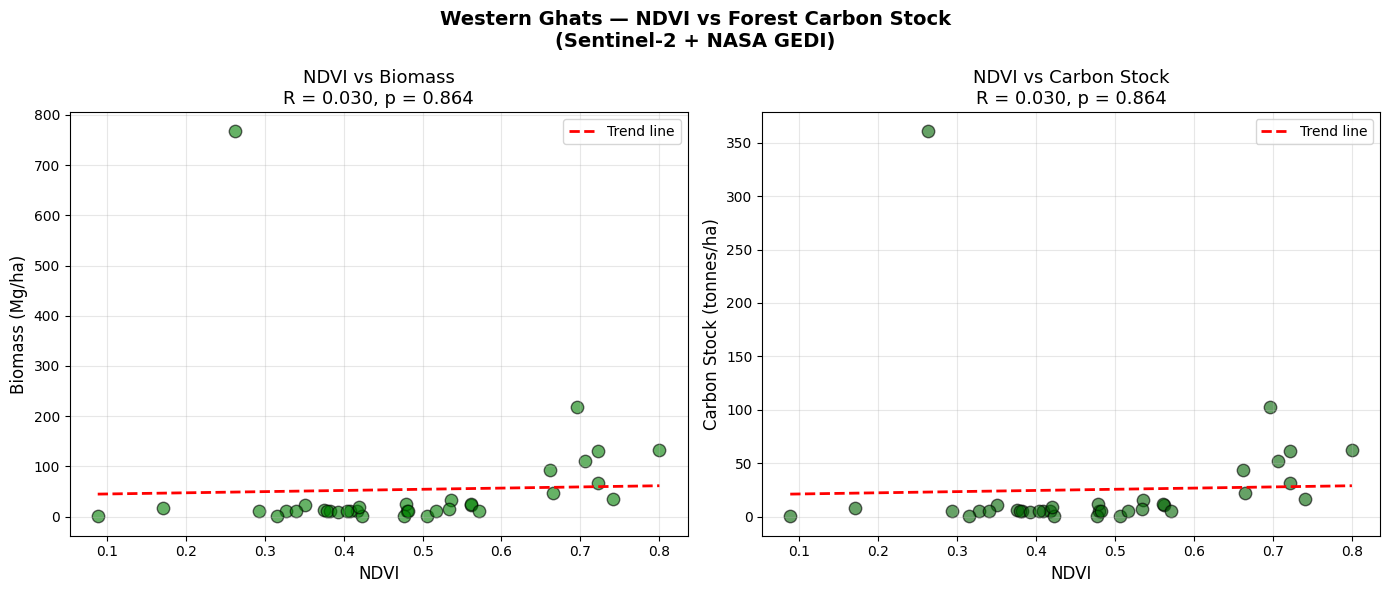


📊 Correlation Results:
NDVI vs Biomass correlation (R): 0.030
NDVI vs Carbon correlation (R):  0.030


In [8]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Create scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 - NDVI vs Biomass
axes[0].scatter(df['NDVI'], df['Biomass_Mgha'],
                color='green', alpha=0.6, edgecolor='black', s=80)

# Add trend line
z = np.polyfit(df['NDVI'], df['Biomass_Mgha'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['NDVI'].min(), df['NDVI'].max(), 100)
axes[0].plot(x_line, p(x_line), "r--", linewidth=2, label='Trend line')

# Calculate R²
r_value, p_value = stats.pearsonr(df['NDVI'], df['Biomass_Mgha'])
axes[0].set_xlabel('NDVI', fontsize=12)
axes[0].set_ylabel('Biomass (Mg/ha)', fontsize=12)
axes[0].set_title(f'NDVI vs Biomass\nR = {r_value:.3f}, p = {p_value:.3f}', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 - NDVI vs Carbon
axes[1].scatter(df['NDVI'], df['Carbon_tonnes_ha'],
                color='darkgreen', alpha=0.6, edgecolor='black', s=80)

# Add trend line
z2 = np.polyfit(df['NDVI'], df['Carbon_tonnes_ha'], 1)
p2 = np.poly1d(z2)
axes[1].plot(x_line, p2(x_line), "r--", linewidth=2, label='Trend line')

r_value2, p_value2 = stats.pearsonr(df['NDVI'], df['Carbon_tonnes_ha'])
axes[1].set_xlabel('NDVI', fontsize=12)
axes[1].set_ylabel('Carbon Stock (tonnes/ha)', fontsize=12)
axes[1].set_title(f'NDVI vs Carbon Stock\nR = {r_value2:.3f}, p = {p_value2:.3f}', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Western Ghats — NDVI vs Forest Carbon Stock\n(Sentinel-2 + NASA GEDI)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ndvi_vs_carbon.png', dpi=150)
plt.show()

print(f"\n📊 Correlation Results:")
print(f"NDVI vs Biomass correlation (R): {r_value:.3f}")
print(f"NDVI vs Carbon correlation (R):  {r_value2:.3f}")

In [9]:
# Extract multiple spectral bands - not just NDVI
# This is what makes our model powerful

# Calculate multiple vegetation indices
evi = sentinel2_large.expression(
    '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))', {
        'NIR': sentinel2_large.select('B8'),
        'RED': sentinel2_large.select('B4'),
        'BLUE': sentinel2_large.select('B2')
    }).rename('EVI')

# SAVI - Soil Adjusted Vegetation Index
savi = sentinel2_large.expression(
    '1.5 * (NIR - RED) / (NIR + RED + 0.5)', {
        'NIR': sentinel2_large.select('B8'),
        'RED': sentinel2_large.select('B4')
    }).rename('SAVI')

# NBR - Normalized Burn Ratio (sensitive to forest structure)
nbr = sentinel2_large.normalizedDifference(['B8', 'B12']).rename('NBR')

# Combine all features
all_features = ndvi_large \
    .addBands(evi) \
    .addBands(savi) \
    .addBands(nbr) \
    .addBands(sentinel2_large.select(['B2','B3','B4','B8','B11','B12'])) \
    .addBands(gedi_large)

# Sample all features together
samples_full = all_features.sample(
    region=study_area_large,
    scale=2000,
    numPixels=1000,
    seed=42
)

data_full = samples_full.getInfo()
features_full = data_full['features']

rows = []
for f in features_full:
    props = f['properties']
    if props.get('agbd') is not None:
        rows.append({
            'NDVI': props.get('NDVI'),
            'EVI': props.get('EVI'),
            'SAVI': props.get('SAVI'),
            'NBR': props.get('NBR'),
            'B2': props.get('B2'),
            'B3': props.get('B3'),
            'B4': props.get('B4'),
            'B8': props.get('B8'),
            'B11': props.get('B11'),
            'B12': props.get('B12'),
            'Biomass_Mgha': props.get('agbd'),
            'Carbon_tonnes_ha': props.get('agbd') * 0.47
        })

df_full = pd.DataFrame(rows).dropna()
print(f"✅ Full dataset created with {len(df_full)} points and {len(df_full.columns)} features")
print(df_full.head())

✅ Full dataset created with 36 points and 12 features
       NDVI       EVI      SAVI       NBR          B2       B3       B4  \
0  0.800142  2.516023  1.200042  0.533028  332.000000   537.00   353.00   
1  0.480064  1.347942  0.719974  0.236846  556.583333   722.00   769.75   
2  0.375139  0.800979  0.562639  0.092707  753.000000  1077.25  1268.00   
3  0.382382  0.736574  0.573498  0.059866  632.500000   950.50  1175.25   
4  0.722207  1.727899  1.083167  0.446809  325.000000   583.00   521.00   

            B8      B11          B12  Biomass_Mgha  Carbon_tonnes_ha  
0  3179.500000  1917.00   968.500000    132.675659         62.357560  
1  2191.190476  1923.00  1352.000000     11.096005          5.215123  
2  2790.500000  2990.00  2317.000000     12.752772          5.993803  
3  2630.500000  3241.25  2333.333333     10.796686          5.074443  
4  3230.000000  2258.00  1235.000000     66.289833         31.156222  


📊 Correlation of Each Feature with Carbon Stock:
Biomass_Mgha    1.000000
EVI             0.353579
NBR             0.296539
NDVI            0.029553
SAVI            0.029484
B2             -0.395449
B3             -0.436900
B4             -0.440049
B8             -0.483559
B12            -0.495063
B11            -0.545589
Name: Carbon_tonnes_ha, dtype: float64


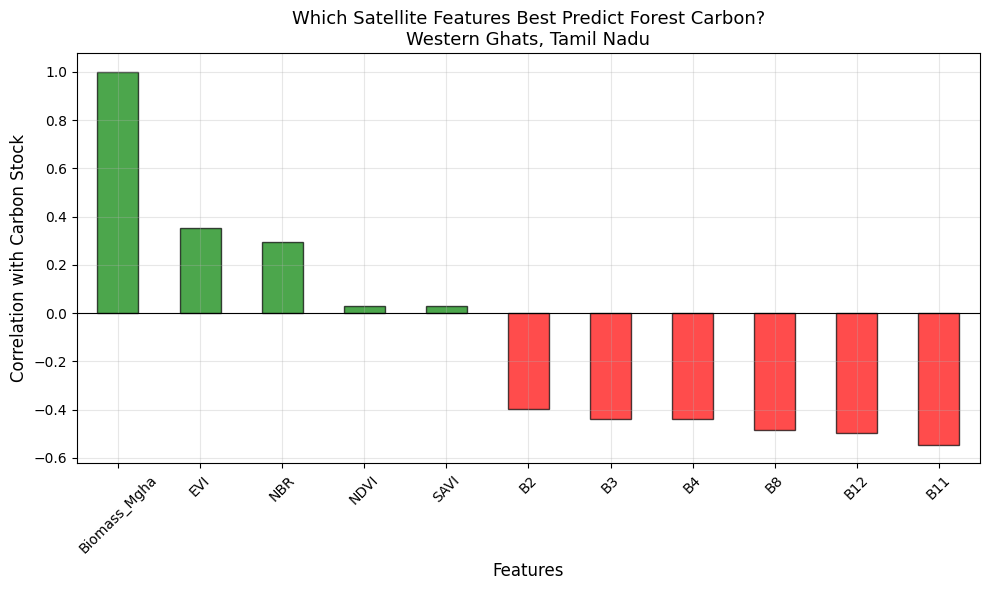

In [10]:
import seaborn as sns

# Calculate correlation of all features with carbon
correlations = df_full.corr()['Carbon_tonnes_ha'].drop('Carbon_tonnes_ha').sort_values(ascending=False)

print("📊 Correlation of Each Feature with Carbon Stock:")
print(correlations)

# Plot correlation bar chart
plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in correlations.values]
correlations.plot(kind='bar', color=colors, edgecolor='black', alpha=0.7)
plt.axhline(y=0, color='black', linewidth=0.8)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Correlation with Carbon Stock', fontsize=12)
plt.title('Which Satellite Features Best Predict Forest Carbon?\nWestern Ghats, Tamil Nadu', fontsize=13)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150)
plt.show()

In [11]:
# Save dataset to CSV
df_full.to_csv('western_ghats_carbon_dataset.csv', index=False)

# Download it to your computer
from google.colab import files
files.download('western_ghats_carbon_dataset.csv')

print(f"✅ Dataset saved!")
print(f"Total samples: {len(df_full)}")
print(f"Features: {list(df_full.columns)}")
print(f"\nCarbon Stock Summary:")
print(f"Mean: {df_full['Carbon_tonnes_ha'].mean():.2f} tonnes/ha")
print(f"Max:  {df_full['Carbon_tonnes_ha'].max():.2f} tonnes/ha")
print(f"Min:  {df_full['Carbon_tonnes_ha'].min():.2f} tonnes/ha")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Dataset saved!
Total samples: 36
Features: ['NDVI', 'EVI', 'SAVI', 'NBR', 'B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'Biomass_Mgha', 'Carbon_tonnes_ha']

Carbon Stock Summary:
Mean: 25.35 tonnes/ha
Max:  360.58 tonnes/ha
Min:  0.14 tonnes/ha


In [ ]:
# Install folium if needed
import folium

# Higher quality visualization with better zoom
m2 = folium.Map(location=[10.75, 77.75], zoom_start=10)

# True color layer
folium.TileLayer(
    tiles=map_id['tile_fetcher'].url_format,
    attr='Google Earth Engine',
    name='Sentinel-2 True Color',
    overlay=True,
    control=True
).add_to(m2)

# Add NDVI layer (shows vegetation health in color)
ndvi = sentinel2.normalizedDifference(['B8', 'B4'])
ndvi_params = {
    'min': -1,
    'max': 1,
    'palette': ['red', 'yellow', 'green']
}

ndvi_map = ndvi.getMapId(ndvi_params)
folium.TileLayer(
    tiles=ndvi_map['tile_fetcher'].url_format,
    attr='Google Earth Engine',
    name='NDVI - Vegetation Health',
    overlay=True,
    control=True
).add_to(m2)

folium.LayerControl().add_to(m2)
m2